In [1]:
import datetime
print(f"run @ {datetime.datetime.today().strftime('%Y%m%d-%H:%M:%S')}")

run @ 20260625-18:30:00


In [2]:
last_pre_week = "2026-05-24"
test_df_start = "2026-05-01"
base_PoM_default = {'dav2shreths':0.16, 'sharethis': 0.15}

In [3]:
#adv_type = "Automotive"
adv_type = "All"

In [4]:
data_path = "/Users/ravirajan/code/data"
output_path = "/Users/ravirajan/code/outputs"
#ttd_file = f"{data_path}/TTD-20260608.csv"
#ttd_file = f"{data_path}/TTD-20260615.csv"
ttd_file = f"{data_path}/TTD-20260623.csv"

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import matplotlib

In [7]:
import seaborn as sns

In [8]:
def get_split_means(dat1_sample, value = 'Avg_Relevance'):
    return dat1_sample.groupby(['week_start', 'Third_Party_Data_Provider_Id'])[[value]].mean().pivot_table(
    index='week_start', columns='Third_Party_Data_Provider_Id', values=value)

def get_split_plots(dat1_sample, x, y, kind='scatter', logx=False, logy=False):
    ax=None
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id == 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='branded taxonomy', color='green')
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id != 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='data alliance', color='orange')
    return ax

from matplotlib.pyplot import cm
def get_split_plots2(dat1_sample, x, y, kind='scatter', by='geo', logx=False, logy=False, alpha=1):
    ax=None
    vals = set(dat1_sample[by].values)
    color = cm.rainbow(np.linspace(0, 1, len(vals)))
    for i, val in enumerate(vals):
        ax=dat1_sample[dat1_sample[by] == val].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label=val, color=color[i], alpha=alpha)
    return ax

In [9]:
dat0 = pd.read_csv(ttd_file, low_memory=False).replace(' ', None)
pricing = pd.read_csv(f"{data_path}/Price_Expt_Assignments2.csv")

In [10]:
dat0['Week_Start_Date'].max()

'2026-06-08 00:00:00+00'

In [11]:
dat0.head(3)

,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,Effective_Impression_Count,Full_Path,...,Match_Pct_Percentile,Paid_Pct,Paid_Pct_Percentile,Received_ID_Count,Selected_Pct,Selected_Pct_Percentile,Third_Party_Data_Provider_Element_Id,Third_Party_Data_Provider_Id,Third_Party_Data_Sub_Provider_Id,Week_Start_Date
0,NaN,NaN,Style & Fashion,3.5,74.6,NaN,NaN,NaN,NaN,Data Alliance > Shopping > Interest > Global >...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
1,NaN,NaN,Style & Fashion,3.7,80.6,NaN,NaN,NaN,NaN,Data Alliance > Travel > Interest > Global > T...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
2,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,NaN,Data Alliance > Education > Interest > Global ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00


In [12]:
pricing.head(3)    

,Unnamed: 0.1,Unnamed: 0,Third_Party_Data_Provider_Id,group,Full_Path,revenue,rev_rank,geo,assignment,incr,bucket
0,0,0.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,2421.51,1,Global,1,0.05,high
1,1,2.0,dav2shreths,0,Data Alliance > Demographic > Interest > Globa...,1983.75,2,Global,-1,0.05,high
2,2,1.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,1336.34,3,Global,0,0.05,high


In [13]:
dat = pd.DataFrame(dat0, copy=True) # prices changed 5-26 so capturing weeks from 5-18
dat['post'] = dat['Week_Start_Date'].apply(lambda x: 1 if x > last_pre_week else 0)

In [14]:
def add_prices(dat, base_PoM_default, pricing):
    dat = dat.set_index('Third_Party_Data_Provider_Id').join(pd.DataFrame([base_PoM_default]).T[[0]]).reset_index()
    cols = list(dat.columns)
    cols[-1] = 'base_PoM'
    dat.columns = cols
    #
    pricing['delta'] = pricing['assignment'] * pricing['incr']
    dat = dat.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).join(
        pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])[['group', 'delta', 'bucket']], how='left').reset_index()
    dat['delta'] = dat['delta'].fillna(0)
    dat['price'] = dat['base_PoM'] + dat['delta'] * dat['post']  # delta only applies post-treatment
    return dat


In [15]:
dat = add_prices(dat, base_PoM_default, pricing)

In [16]:
def get_geo(litems):
    check = ['Asia', 'US', 'Global', 'APAC']
    for c in check:
        if c in litems:
            return c
    return 'Unknown'

In [17]:
dat['geo'] = dat.Full_Path.apply(lambda x: get_geo(x.replace(" ", "").split(">")))

In [18]:
dat.groupby('geo')[['Data_Cost']].sum() / dat['Data_Cost'].sum()

,Data_Cost
geo,
APAC,0.013609
Asia,0.013927
Global,0.477024
US,0.329877
Unknown,0.165564


In [19]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,4140.0,0.150000,1.168651e-14,0.15,0.15,0.15,0.15,0.15
Asia,420900.0,0.150016,4.045566e-04,0.15,0.15,0.15,0.15,0.16
Global,1091235.0,0.156775,1.272206e-02,0.10,0.15,0.16,0.16,0.21
US,286695.0,0.150000,8.029424e-13,0.15,0.15,0.15,0.15,0.15
Unknown,176940.0,0.150019,4.411375e-04,0.15,0.15,0.15,0.15,0.16


In [20]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,4140.0,0.150000,1.168651e-14,0.15,0.15,0.15,0.15,0.15
Asia,420900.0,0.150016,4.045566e-04,0.15,0.15,0.15,0.15,0.16
Global,1091235.0,0.156775,1.272206e-02,0.10,0.15,0.16,0.16,0.21
US,286695.0,0.150000,8.029424e-13,0.15,0.15,0.15,0.15,0.15
Unknown,176940.0,0.150019,4.411375e-04,0.15,0.15,0.15,0.15,0.16


In [21]:
dat['Clean_Path'] = dat.Full_Path.apply(lambda x: x.lower().replace(" ", ""))
dat['segment_last'] = dat.Clean_Path.apply(lambda x: x.split(">")[-1].replace("age", ""))
dat['segment_1'] = dat.Clean_Path.apply(lambda x: x.split(">")[0])
##dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.replace("otp>", "").split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['week_start'] = dat.Week_Start_Date.apply(lambda x: x.split(" ")[0])

In [22]:
len(dat['segment_last'].unique()), len(dat['segment_1'].unique()), len(dat['segment_2'].unique())

(3208, 19, 82)

# EDA

In [23]:
dat1 = dat[dat.Received_ID_Count.isna() == False]
dat1 = dat1[dat1.Advertiser_Category == adv_type]
dat1.shape

(89560, 33)

In [24]:
dat1['Received_ID_Count'] = dat1['Received_ID_Count'].astype(int)
dat1['Active_ID_Count'] = dat1['Active_ID_Count'].astype(int)
dat1['Effective_Impression_Count'] = dat1['Effective_Impression_Count'].astype(int)

In [25]:
dat['Data_Cost'] = dat['Data_Cost'].astype(float)
dat1['Match_Pct'] = dat1['Match_Pct'].astype(float)
dat1['Match_Pct_Percentile'] = dat1['Match_Pct_Percentile'].astype(float)

<Axes: title={'center': 'avg(revenue) over time'}, xlabel='week_start', ylabel='revenue'>

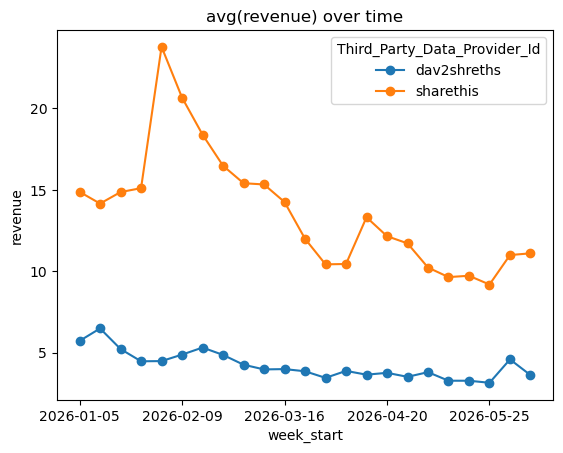

In [26]:
get_split_means(dat1, value = 'Data_Cost').plot(marker='o', title='avg(revenue) over time', ylabel='revenue')

<Axes: xlabel='week_start'>

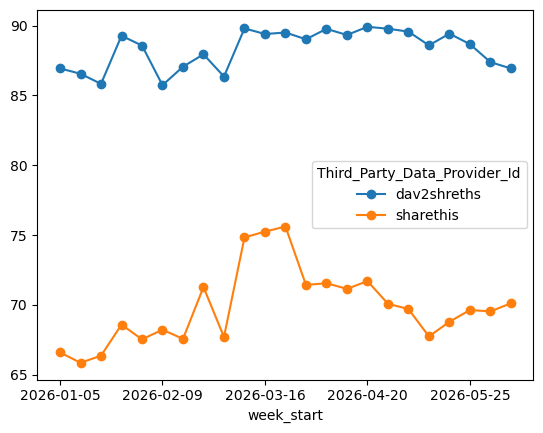

In [27]:
get_split_means(dat1, value = 'Avg_Relevance_Percentile').plot(marker='o')

## filter out bad rows

In [28]:
#dat1.head()

In [29]:
dat2 = dat1[dat1.Received_ID_Count > 0]

# also filter out rows not belonging to pricing experiment
dat2 = dat2[~dat2.group.isna()]

# Model

In [30]:
yr = dat2['Avg_Relevance_Percentile'] #['Avg_Relevance']
yd = dat2['Data_Cost'].astype(float) 

In [31]:
#seg_col = 'segment_last'
seg_col = 'segment_2'
#seg_col = 'Full_Path'

In [32]:
x_c_cols = list(dict.fromkeys([seg_col, 'week_start', 'Advertiser_Category', 'Third_Party_Data_Provider_Id', 'geo', 'segment_2']))
x_n_cols = ['Received_ID_Count', 'price', 'Avg_Relevance_Percentile'] #[ 'Active_ID_Count_Percentile', 'Paid_Pct_Percentile']
# 'Avg_Value_Percentile' has NAs

In [33]:
Xn = pd.DataFrame(dat2[x_n_cols], dtype=float)
Xn['log_Received_ID_Count'] = Xn['Received_ID_Count'].apply(lambda x: np.log(x))
x_n_cols += ['log_Received_ID_Count']

In [34]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
Xn = pd.DataFrame(sc.fit_transform(Xn), columns=Xn.columns, index=Xn.index)

In [35]:
Xc = pd.get_dummies(dat2[x_c_cols])

In [36]:
X = Xn.join(Xc)
X.head()

,Received_ID_Count,price,Avg_Relevance_Percentile,log_Received_ID_Count,segment_2_arts&entertainment,segment_2_automotive,segment_2_autos&vehicles,segment_2_beauty&fitness,segment_2_books&literature,segment_2_business&finance,...,week_start_2026-05-04,week_start_2026-05-11,week_start_2026-05-18,week_start_2026-05-25,week_start_2026-06-01,week_start_2026-06-08,Advertiser_Category_All,Third_Party_Data_Provider_Id_dav2shreths,Third_Party_Data_Provider_Id_sharethis,geo_Global
78,-0.821955,0.353759,0.371469,-0.440450,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
88,-0.368923,0.353759,0.546917,0.122446,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
208,-0.904071,0.353759,0.706416,-0.597399,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
297,-1.236747,0.353759,0.594767,-2.006720,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True
312,-1.309431,0.353759,0.722366,-3.916418,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True


# Revenue model

## Ridge

In [37]:
from sklearn.linear_model import Ridge

mod_d = Ridge(alpha=0.000001)
mod_d.fit(X, yd)
mod_d.score(X, yd)

0.02502715924198251

In [38]:
coef_d = pd.DataFrame(mod_d.coef_, index=X.columns, columns=['beta'])
coef_d['abs_beta'] = coef_d['beta'].abs()
coef_d_sorted = coef_d.sort_values('abs_beta', ascending=False)

In [39]:
coef_d_sorted[coef_d_sorted.beta > 0].filter(regex=seg_col, axis='index').head(15)

,beta,abs_beta
segment_2_people&society,71.364737,71.364737
segment_2_travel,44.985435,44.985435
segment_2_validateddemographic,41.836053,41.836053
segment_2_demographic,39.259920,39.259920
segment_2_law&government,16.561890,16.561890
segment_2_business&finance,15.083711,15.083711
segment_2_realestate,13.973694,13.973694
segment_2_health&wellness,6.055458,6.055458
segment_2_career&jobs,5.622779,5.622779
segment_2_hobbies&leisure,5.588705,5.588705


### some interesting betas

In [40]:
coef_d.filter(regex='Received', axis='index')

,beta,abs_beta
Received_ID_Count,6.831143,6.831143
log_Received_ID_Count,3.747449,3.747449


In [41]:
coef_d.filter(regex='Rel', axis='index')

,beta,abs_beta
Avg_Relevance_Percentile,2.782753,2.782753


In [42]:
coef_d.filter(regex='price', axis='index')

,beta,abs_beta
price,-0.620705,0.620705


In [43]:
coef_d.filter(regex='geo_', axis='index')

,beta,abs_beta
geo_Global,0.0,0.0


In [44]:
coef_d.filter(regex='Third_Party_Data_Provider_Id', axis='index')

,beta,abs_beta
Third_Party_Data_Provider_Id_dav2shreths,-2.904367,2.904367
Third_Party_Data_Provider_Id_sharethis,2.904368,2.904368


In [45]:
import matplotlib.pyplot as plt

def dfScatter(df, xcol='beta', ycol='Received_ID_Count', catcol='criterion', logx=False, logy=False):
    #fig, ax = plt.subplots()
    categories = np.unique(df[catcol])
    colors = np.linspace(0, 1, len(categories))
    colordict = dict(zip(categories, colors))  
    colors = df[catcol].apply(lambda x: colordict[x])
    return df.plot(kind='scatter', x=xcol, y=ycol, logy=logy, logx=logx, c=colors)

# RF to forecast demand curves

In [46]:
from sklearn.ensemble import RandomForestRegressor as RFR

In [47]:
X_rf = X[X.columns[X.columns != 'log_Received_ID_Count']]

In [48]:
mod_d_rf = RFR(max_depth=5)
mod_d_rf.fit(X_rf, yd)
mod_d_rf.score(X_rf, yd)

0.34771861038320306

In [49]:
coef_d_rf = pd.DataFrame(mod_d_rf.feature_importances_, index=X_rf.columns, columns=['feature_importance'])
coef_d_rf_sorted = coef_d_rf.sort_values('feature_importance', ascending=False)
coef_d_rf_sorted.head(20)

,feature_importance
Received_ID_Count,0.505719
Avg_Relevance_Percentile,0.289882
week_start_2026-02-16,0.035545
week_start_2026-02-09,0.030057
week_start_2026-02-02,0.026881
segment_2_travel,0.020051
segment_2_people&society,0.017049
week_start_2026-02-23,0.016406
week_start_2026-01-05,0.014751
week_start_2026-01-26,0.008743


In [50]:
def sweep_forecast(X_rf, mod, sc, 
                   vary_feature, grid_unscaled, 
                   n_rows=1000,
                   geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']
                  ):
    """
    Sweep vary_feature across grid_unscaled, averaging revenue over n_rows real data rows.

    vary_feature : numeric feature name in sc.feature_names_in_
                   e.g. 'Received_ID_Count', 'price', 'Avg_Relevance_Percentile'
    grid_unscaled: array of raw (unscaled) values to sweep over
    n_rows       : number of real data rows to average over

    Returns DataFrame with columns: [vary_feature + '_unscaled', 'geo', 'revenue_forecast']
    """
    grid_unscaled = np.asarray(grid_unscaled)
    feat_idx = list(sc.feature_names_in_).index(vary_feature)
    grid_scaled = (grid_unscaled - sc.mean_[feat_idx]) / sc.scale_[feat_idx]

    X_rf2 = X_rf[X_rf.columns[X_rf.columns != vary_feature]]
    
    forecast_list = []
    for idx in range(min(n_rows, len(X_rf2))):
        samples_vary = pd.DataFrame(
            {vary_feature: grid_scaled},
            index=[X_rf2.index[idx]] * len(grid_scaled)
        )
        temp = samples_vary.join(X_rf2.iloc[[idx]])
        forecast_list.append(temp)

    fc = pd.concat(forecast_list)
    fc['revenue_forecast'] = mod.predict(fc[X_rf.columns])
    fc[vary_feature + '_unscaled'] = fc[vary_feature] * sc.scale_[feat_idx] + sc.mean_[feat_idx]
    fc['geo'] = fc.reindex(columns=geos).apply(
        lambda x: next((g.split('_')[1] for g in geos if x[g] == 1), 'Unknown'), axis=1
    )

    return fc.groupby(['geo', vary_feature + '_unscaled'])[['revenue_forecast']].mean().reset_index()


In [51]:
def extract_geo(x, geos):
    for geo in geos:
        if x[geo] == 1:
            return geo.split('_')[1]
    return "Unknown"

geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']


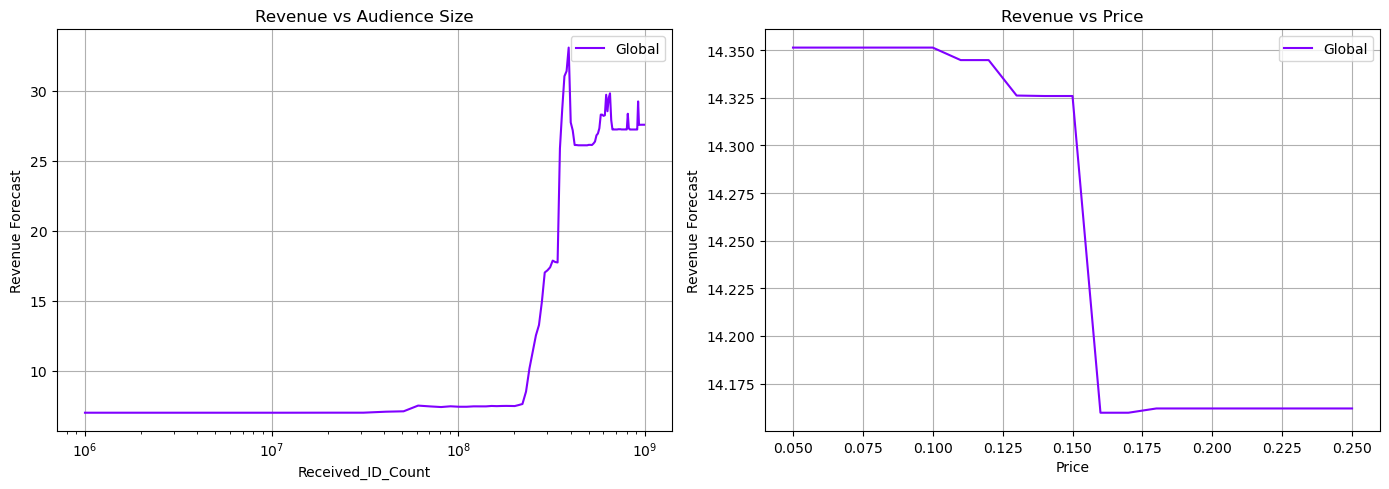

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Size sweep ---
size_grid = np.arange(1, 1000, 10) * 1_000_000
fc_size = sweep_forecast(X_rf, mod_d_rf, sc, 'Received_ID_Count', size_grid)
geos = fc_size['geo'].unique()
color = plt.cm.rainbow(np.linspace(0, 1, len(geos)))
for i, geo in enumerate(geos):
    sub = fc_size[fc_size['geo'] == geo]
    axes[0].plot(sub['Received_ID_Count_unscaled'], sub['revenue_forecast'], label=geo, color=color[i])
axes[0].set_xscale('log')
axes[0].set_xlabel('Received_ID_Count')
axes[0].set_ylabel('Revenue Forecast')
axes[0].set_title('Revenue vs Audience Size')
axes[0].legend()
axes[0].grid(True)

# --- Price sweep ---
price_grid = np.arange(0.05, 0.26, 0.01)
fc_price = sweep_forecast(X_rf, mod_d_rf, sc, 'price', price_grid)
geos_p = fc_price['geo'].unique()
color_p = plt.cm.rainbow(np.linspace(0, 1, len(geos_p)))
for i, geo in enumerate(geos_p):
    sub = fc_price[fc_price['geo'] == geo]
    axes[1].plot(sub['price_unscaled'], sub['revenue_forecast'], label=geo, color=color_p[i])
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Revenue Forecast')
axes[1].set_title('Revenue vs Price')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## DID

In [53]:
relative = True

In [54]:
#test = dat[~dat.group.isna()] # all adv_types
test = dat1[~dat1.group.isna()]
#test = dat2[~dat2.group.isna()]
test = test[test.Week_Start_Date > test_df_start]
test = test[test.Third_Party_Data_Provider_Id == 'sharethis']
test_means = test.groupby(['group', 'Full_Path', 'delta', 'post'])[['Data_Cost']].mean()

In [55]:
test_means_joined = test_means.xs(0, level='post').join(
    test_means.xs(1, level='post'), lsuffix='_pre', rsuffix='_post'
).reset_index()
test_means_joined['chg'] = test_means_joined['Data_Cost_post'] - test_means_joined['Data_Cost_pre']
test_means_joined['chg_ratio'] = test_means_joined['chg'] / test_means_joined['Data_Cost_pre']

In [56]:
test_means_joined.groupby('delta')[['chg']].describe()

chg                                                                  \
       count      mean         std         min       25%       50%       75%   
delta                                                                          
-0.05  224.0  2.213757   39.731348 -391.640000 -0.006667  0.228333  2.712500   
 0.00  234.0  7.924865  115.426114  -50.616667 -0.392500  0.000000  0.330833   
 0.05  236.0 -3.175466   18.596606 -166.996667 -1.465000 -0.040000  0.060000   

                    
               max  
delta               
-0.05   161.540000  
 0.00  1757.960000  
 0.05    62.073333

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>]],
      dtype=object)

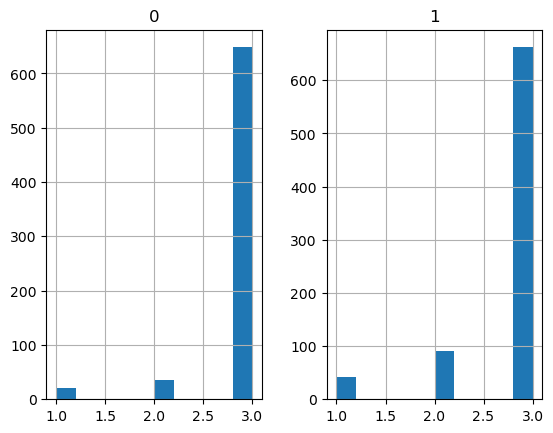

In [57]:
pd.DataFrame(test.groupby(['Full_Path','post']).size()).pivot_table(index='Full_Path', columns='post', values=0).hist()

In [58]:
import numpy as np
from scipy import stats

# --- compute DiD ---
control_mean_by_group = (
    test_means_joined[test_means_joined['delta'] == 0]
    .groupby('group')['chg']
    .mean()
    .rename('control_chg_mean')
)
did = (
    test_means_joined
    .join(control_mean_by_group, on='group')
    .dropna(subset=['control_chg_mean'])
    .copy()
)
did['did'] = did['chg'] - did['control_chg_mean']
control_level_by_group = (
    test_means_joined[test_means_joined['delta'] == 0]
    .groupby('group')['Data_Cost_pre']
    .mean()
    .rename('control_level')
)
did = did.join(control_level_by_group, on='group')
did['did_rel'] = (did['did'] / did['control_level']).replace([np.inf, -np.inf], np.nan)

did_col   = 'did_rel' if relative else 'did'
did_label = 'Relative DiD  (chg / control pre-level)' if relative else 'DiD  (post−pre vs control)'

# --- shared functions ---
def ttest_trimmed(vals, trim=0.1):
    a = np.sort(vals)
    k = int(np.floor(trim * len(a)))
    return stats.ttest_1samp(a[k: len(a) - k], popmean=0)

def wilcoxon_safe(vals):
    try:
        _, p = stats.wilcoxon(vals)
        return p
    except ValueError:
        return 1.0  # all values zero — no evidence against null

def p_label(p):
    if p < 0.001: return 'p<0.001'
    if p < 0.05:  return f'p={p:.3f}'
    return f'p={p:.3f} (n.s.)'

def desc_stats(did, col):
    rows = []
    for d in sorted(did['delta'].unique()):
        vals = did[did['delta'] == d][col].dropna().values
        _, p_t     = stats.ttest_1samp(vals, popmean=0)
        _, p_trim  = ttest_trimmed(vals)
        p_wilcox   = wilcoxon_safe(vals)
        q = lambda pct: round(float(np.quantile(vals, pct)), 3)
        rows.append({
            'delta': d, 'n': len(vals),
            'mean':  round(float(vals.mean()), 3),
            'std':   round(float(vals.std()),  3),
            'cdf0':  round(float((vals <= 0).mean()), 3),
            'p5':    q(0.05), 'q25': q(0.25), 'median': q(0.50),
            'q75':   q(0.75), 'p95': q(0.95),
            'p_t':      round(float(p_t),      4),
            'p_trim':   round(float(p_trim),   4),   # drops top/bottom 10%
            'p_wilcox': round(float(p_wilcox), 4),   # rank-based
        })
    return pd.DataFrame(rows)

def plot_did_bars(ax, did, col, metric='mean'):
    """One bar chart panel. metric='mean' uses trimmed-t; 'median' uses Wilcoxon."""
    deltas = sorted(did['delta'].unique())
    centers, spreads, pvals = [], [], []
    for d in deltas:
        vals = did[did['delta'] == d][col].dropna().values
        if metric == 'mean':
            _, p = ttest_trimmed(vals)
            centers.append(float(vals.mean()))
            spreads.append(1.96 * float(stats.sem(vals)))
        else:
            p = wilcoxon_safe(vals)
            centers.append(float(np.median(vals)))
            spreads.append((float(np.quantile(vals, 0.75)) - float(np.quantile(vals, 0.25))) / 2)
        pvals.append(float(p))
    ax.bar([str(d) for d in deltas], centers, yerr=spreads, capsize=5,
           color=['steelblue', 'brown', 'tomato'])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ylo, yhi = ax.get_ylim()
    new_yhi = yhi + (yhi - ylo) * 0.08 * len(deltas)
    ax.set_ylim(ylo, new_yhi)
    for i, (p, center, spread) in enumerate(zip(pvals, centers, spreads)):
        ax.text(i, center + spread + (new_yhi - ylo) * 0.02,
                p_label(p), ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.4)

 delta   n   mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 178  8.826 52.350 0.360  -5.321 -0.248   0.415 1.530 18.147 0.0261  0.0000    0.0000
  0.00 206  0.000  0.000 1.000   0.000  0.000   0.000 0.000  0.000    NaN     NaN    1.0000
  0.05 183 -4.137 26.535 0.601 -20.164 -0.945  -0.153 0.583  9.767 0.0368  0.0037    0.0787


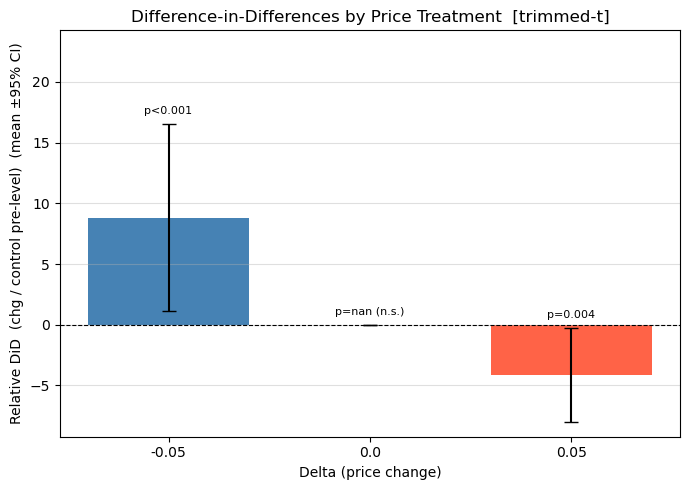

In [59]:
# --- overview: stats table + single bar chart ---
print(desc_stats(did, did_col).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
plot_did_bars(ax, did, did_col, metric='mean')
ax.set_xlabel('Delta (price change)')
ax.set_ylabel(f'{did_label}  (mean ±95% CI)')
ax.set_title('Difference-in-Differences by Price Treatment  [trimmed-t]')
plt.tight_layout()
plt.show()

=== Relative DiD  (chg / control pre-level) ===
 delta   n   mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 178  8.826 52.350 0.360  -5.321 -0.248   0.415 1.530 18.147 0.0261  0.0000    0.0000
  0.00 206  0.000  0.000 1.000   0.000  0.000   0.000 0.000  0.000    NaN     NaN    1.0000
  0.05 183 -4.137 26.535 0.601 -20.164 -0.945  -0.153 0.583  9.767 0.0368  0.0037    0.0787

=== raw (chg) ===
 delta   n   mean     std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 198  2.132  41.969 0.313  -6.152 -0.006   0.338 3.140 24.503 0.4768  0.0000    0.0000
  0.00 234  7.925 115.179 0.568  -6.471 -0.393   0.000 0.331  7.835 0.2947  0.3613    0.5335
  0.05 204 -3.652  19.916 0.676 -21.769 -1.948  -0.067 0.102  6.329 0.0097  0.0000    0.0000


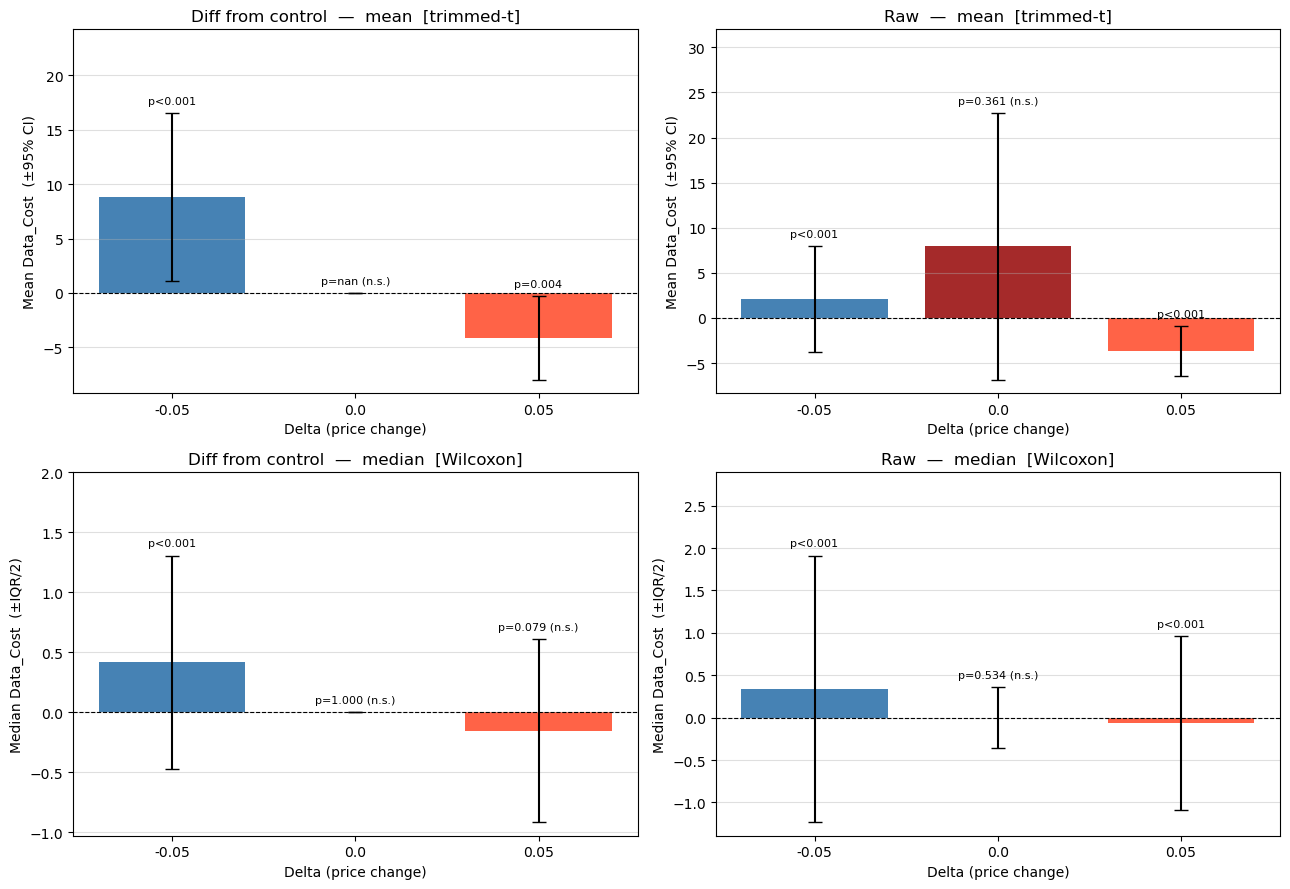

In [60]:
print(f'=== {did_label} ===')
print(desc_stats(did, did_col).to_string(index=False))
print()
print('=== raw (chg) ===')
print(desc_stats(did, 'chg').to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, metric in enumerate(['mean', 'median']):
    for col, value in enumerate(['diff from control', 'raw']):
        ax = axes[row][col]
        dcol = did_col if value == 'diff from control' else 'chg'
        spread_label = '±95% CI' if metric == 'mean' else '±IQR/2'
        p_method = 'trimmed-t' if metric == 'mean' else 'Wilcoxon'
        plot_did_bars(ax, did, dcol, metric=metric)
        ax.set_xlabel('Delta (price change)')
        ax.set_ylabel(f'{metric.capitalize()} Data_Cost  ({spread_label})')
        ax.set_title(f'{value.capitalize()}  —  {metric}  [{p_method}]')
plt.tight_layout()
plt.show()


# analysis by bucket

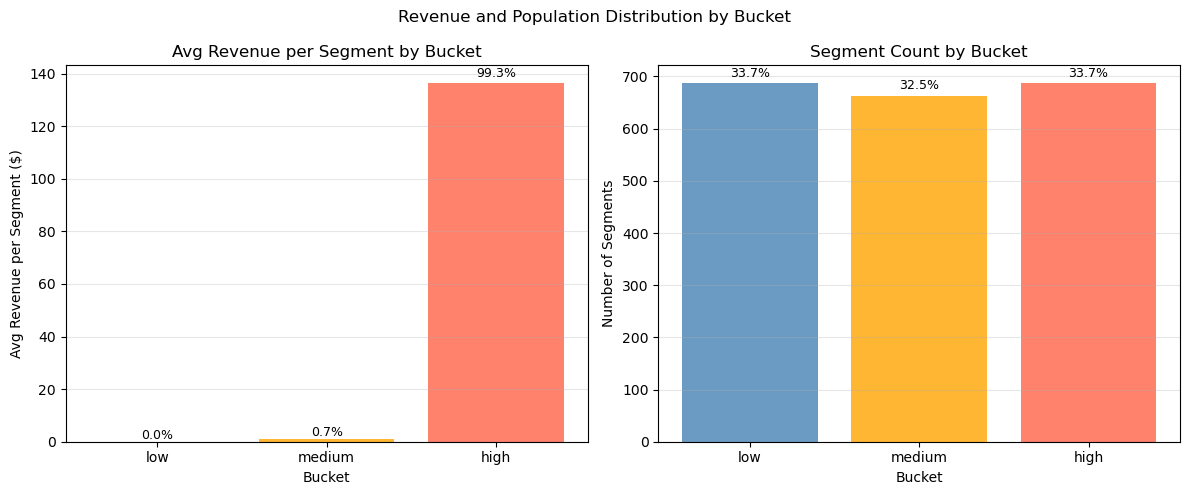

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# step 1: avg revenue per segment (Full_Path)
seg_rev = (
    pricing.groupby("Full_Path")
    .agg(revenue=("revenue", "mean"), bucket=("bucket", "first"))
)

# step 2: avg of those per-segment revenues by bucket
rev_by_bucket = seg_rev.groupby("bucket")["revenue"].mean().reindex(["low", "medium", "high"])
axes[0].bar(rev_by_bucket.index, rev_by_bucket.values, color=["steelblue", "orange", "tomato"], alpha=0.8)
axes[0].set_title("Avg Revenue per Segment by Bucket")
axes[0].set_xlabel("Bucket")
axes[0].set_ylabel("Avg Revenue per Segment ($)")
for i, v in enumerate(rev_by_bucket.values):
    pct = v / rev_by_bucket.sum() * 100
    axes[0].text(i, v * 1.01, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# segment count by bucket
pop_by_bucket = seg_rev.groupby("bucket").size().reindex(["low", "medium", "high"])
axes[1].bar(pop_by_bucket.index, pop_by_bucket.values, color=["steelblue", "orange", "tomato"], alpha=0.8)
axes[1].set_title("Segment Count by Bucket")
axes[1].set_xlabel("Bucket")
axes[1].set_ylabel("Number of Segments")
for i, v in enumerate(pop_by_bucket.values):
    pct = v / pop_by_bucket.sum() * 100
    axes[1].text(i, v * 1.01, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Revenue and Population Distribution by Bucket")
plt.tight_layout()
plt.show()

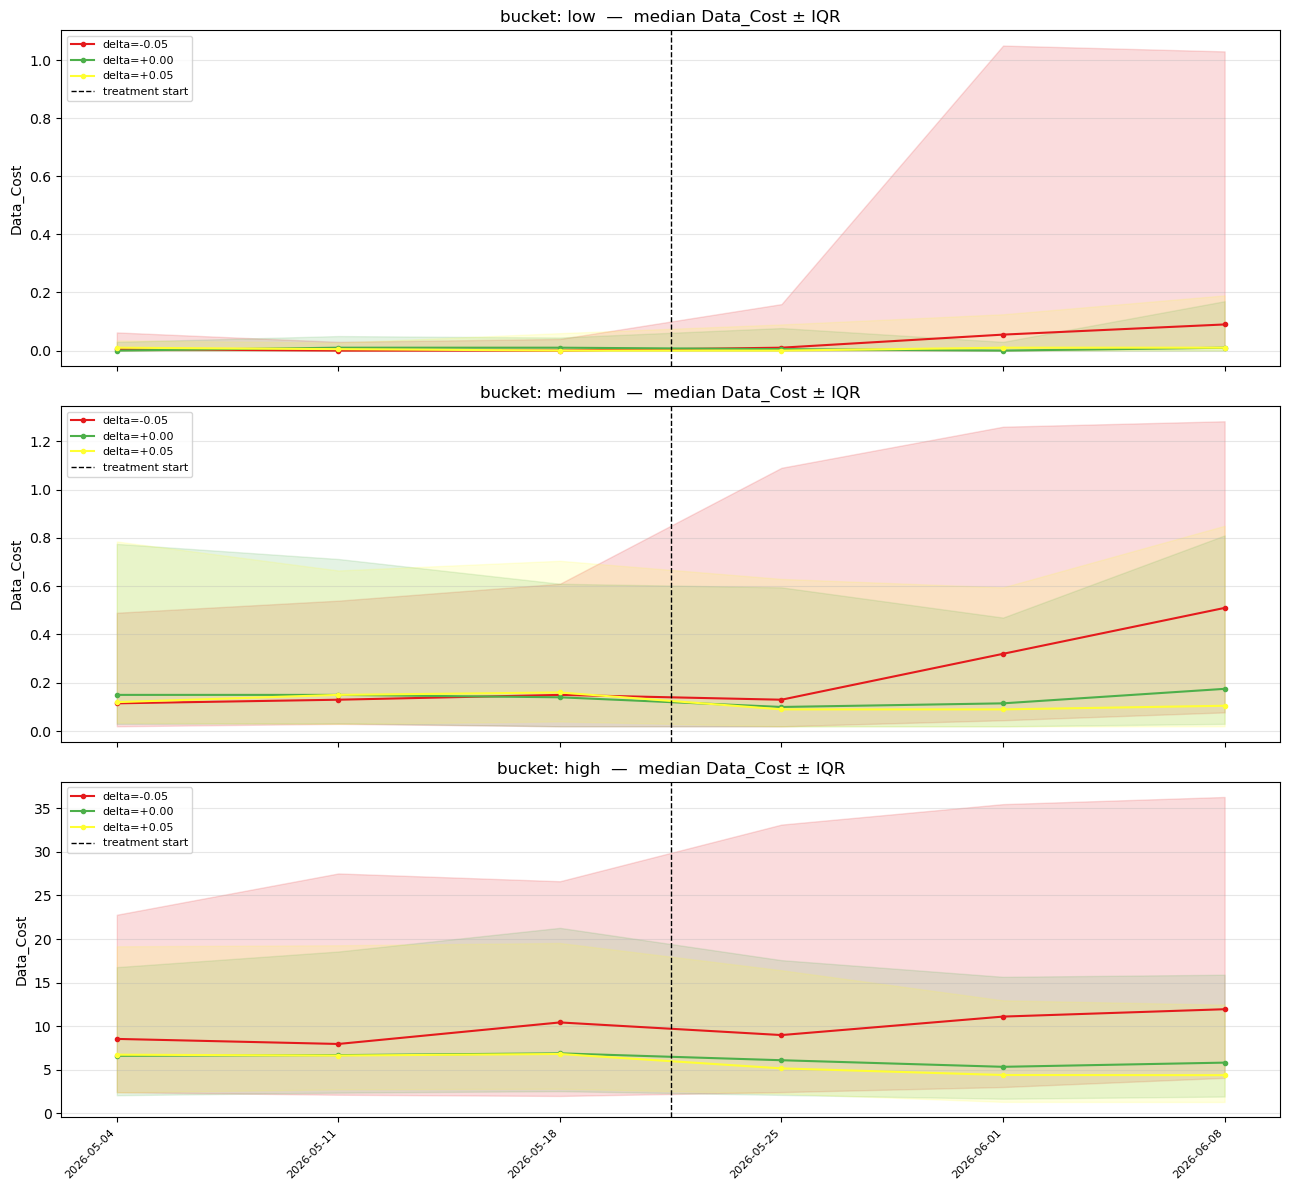

In [62]:
import matplotlib.pyplot as plt

buckets = ['low', 'medium', 'high']
delta_vals = sorted(test['delta'].unique())
dates_all = sorted(test['Week_Start_Date'].unique())
xs = list(range(len(dates_all)))
colors = plt.cm.Set1([0, 0.33, 0.66])  # one color per delta

fig, axes = plt.subplots(len(buckets), 1, figsize=(13, 4 * len(buckets)), sharex=True)

for ax, bucket in zip(axes, buckets):
    sub = test[test['bucket'] == bucket]

    for color, delta in zip(colors, delta_vals):
        grp = sub[sub['delta'] == delta].groupby('Week_Start_Date')['Data_Cost']
        medians = [grp.get_group(d).median() if d in grp.groups else np.nan for d in dates_all]
        q25     = [grp.get_group(d).quantile(0.25) if d in grp.groups else np.nan for d in dates_all]
        q75     = [grp.get_group(d).quantile(0.75) if d in grp.groups else np.nan for d in dates_all]

        ax.plot(xs, medians, marker='o', markersize=3, linewidth=1.5,
                label=f'delta={delta:+.2f}', color=color)
        ax.fill_between(xs, q25, q75, alpha=0.15, color=color)

    treat_idx = next((i for i, d in enumerate(dates_all) if str(d) > last_pre_week), None)
    if treat_idx is not None:
        ax.axvline(treat_idx - 0.5, color='black', linestyle='--', linewidth=1, label='treatment start')

    ax.set_title(f'bucket: {bucket}  —  median Data_Cost ± IQR')
    ax.set_ylabel('Data_Cost')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xticks(xs)
axes[-1].set_xticklabels([str(d)[:10] for d in dates_all], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


In [63]:
import matplotlib.ticker as mtick
import numpy as np

# join bucket from pricing into did
bucket_lookup = pricing[['Full_Path', 'bucket']].drop_duplicates().set_index('Full_Path')
did_b = did.join(bucket_lookup, on='Full_Path')
buckets = ['low', 'medium', 'high']

# extract segment_2 from Full_Path
did_b['segment_2'] = did_b['Full_Path'].apply(
    lambda x: x.lower().replace(" ", "").replace("otp>", "").split(">")[1]
    if len(x.replace(" ", "").split(">")) > 1 else "N/A"
)

# ── stats by bucket ──────────────────────────────────────────────────────────
for bucket in buckets:
    sub = did_b[did_b['bucket'] == bucket]
    print(f"=== bucket: {bucket}  (n={len(sub)}) ===")
    print(desc_stats(sub, did_col).to_string(index=False))
    print()


=== bucket: low  (n=79) ===
 delta  n    mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05  9  20.816 52.504 0.333  -0.538 -0.111   0.783 1.400 107.60 0.2947  0.2947    0.0977
  0.00 21   0.000  0.000 1.000   0.000  0.000   0.000 0.000   0.00    NaN     NaN    1.0000
  0.05  9 -18.933 40.355 0.667 -94.300 -4.333  -1.500 0.323   6.62 0.2211  0.2211    0.2500

=== bucket: medium  (n=240) ===
 delta  n   mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 64 13.070 72.268 0.359 -14.148 -0.150    0.56 2.037 37.290 0.1561  0.0142    0.0182
  0.00 79  0.000  0.000 1.000   0.000  0.000    0.00 0.000  0.000    NaN     NaN    1.0000
  0.05 69 -5.009 34.475 0.493 -50.877 -0.533    0.07 0.934 23.797 0.2350  0.4082    0.4276

=== bucket: high  (n=323) ===
 delta   n   mean    std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 105  5.211 34.493 0.362 -1.633 -0.358   0.352 1.105 4.932 0.1265  0.0000    0.0

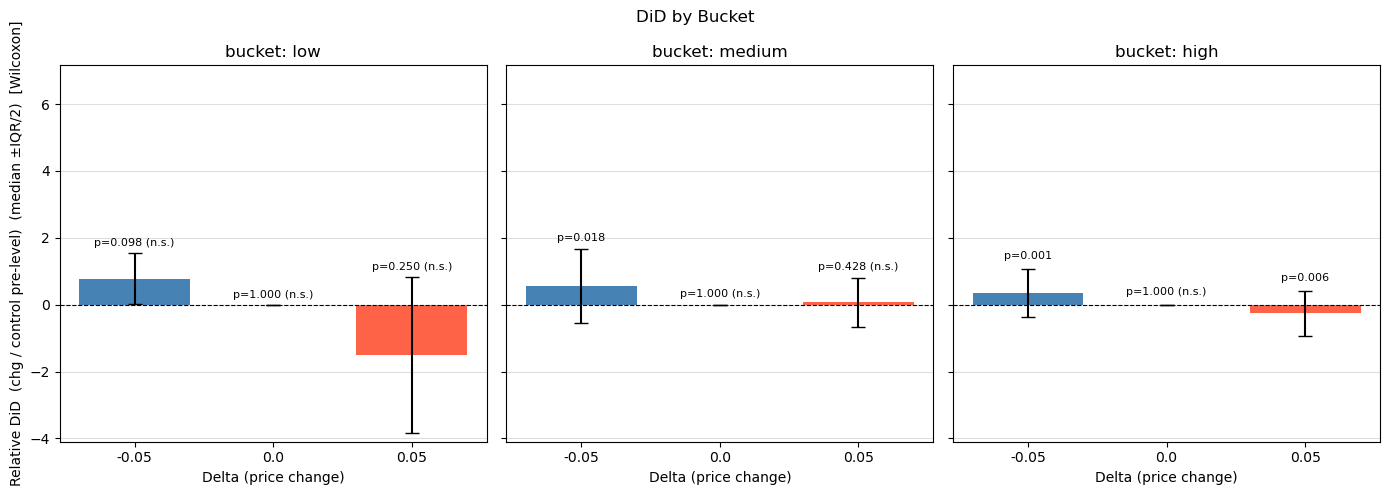

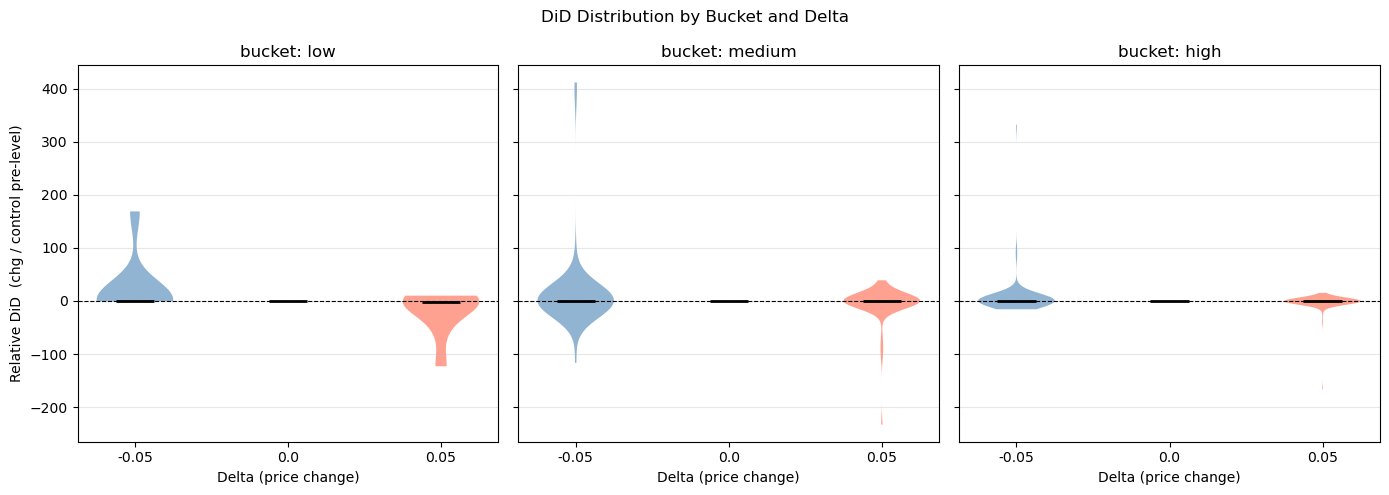

In [64]:
# ── 1. per-bucket bar charts (median DiD by delta) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, bucket in zip(axes, buckets):
    sub = did_b[did_b['bucket'] == bucket]
    plot_did_bars(ax, sub, did_col, metric='median')
    ax.set_title(f'bucket: {bucket}')
    ax.set_xlabel('Delta (price change)')
axes[0].set_ylabel(f'{did_label}  (median ±IQR/2)  [Wilcoxon]')
fig.suptitle('DiD by Bucket')
plt.tight_layout()
plt.show()

# ── 2. violin distributions by (bucket, delta) ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
deltas = sorted(did_b['delta'].unique())
colors = ['steelblue', 'brown', 'tomato']

for ax, bucket in zip(axes, buckets):
    sub = did_b[did_b['bucket'] == bucket]
    data = [sub[sub['delta'] == d][did_col].dropna().values for d in deltas]
    parts = ax.violinplot(data, positions=list(range(len(deltas))),
                          showmedians=True, showextrema=False)
    for body, color in zip(parts['bodies'], colors):
        body.set_facecolor(color); body.set_alpha(0.6)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(deltas)))
    ax.set_xticklabels([str(d) for d in deltas])
    ax.set_xlabel('Delta (price change)')
    ax.set_title(f'bucket: {bucket}')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel(did_label)
fig.suptitle('DiD Distribution by Bucket and Delta')
plt.tight_layout()
plt.show()

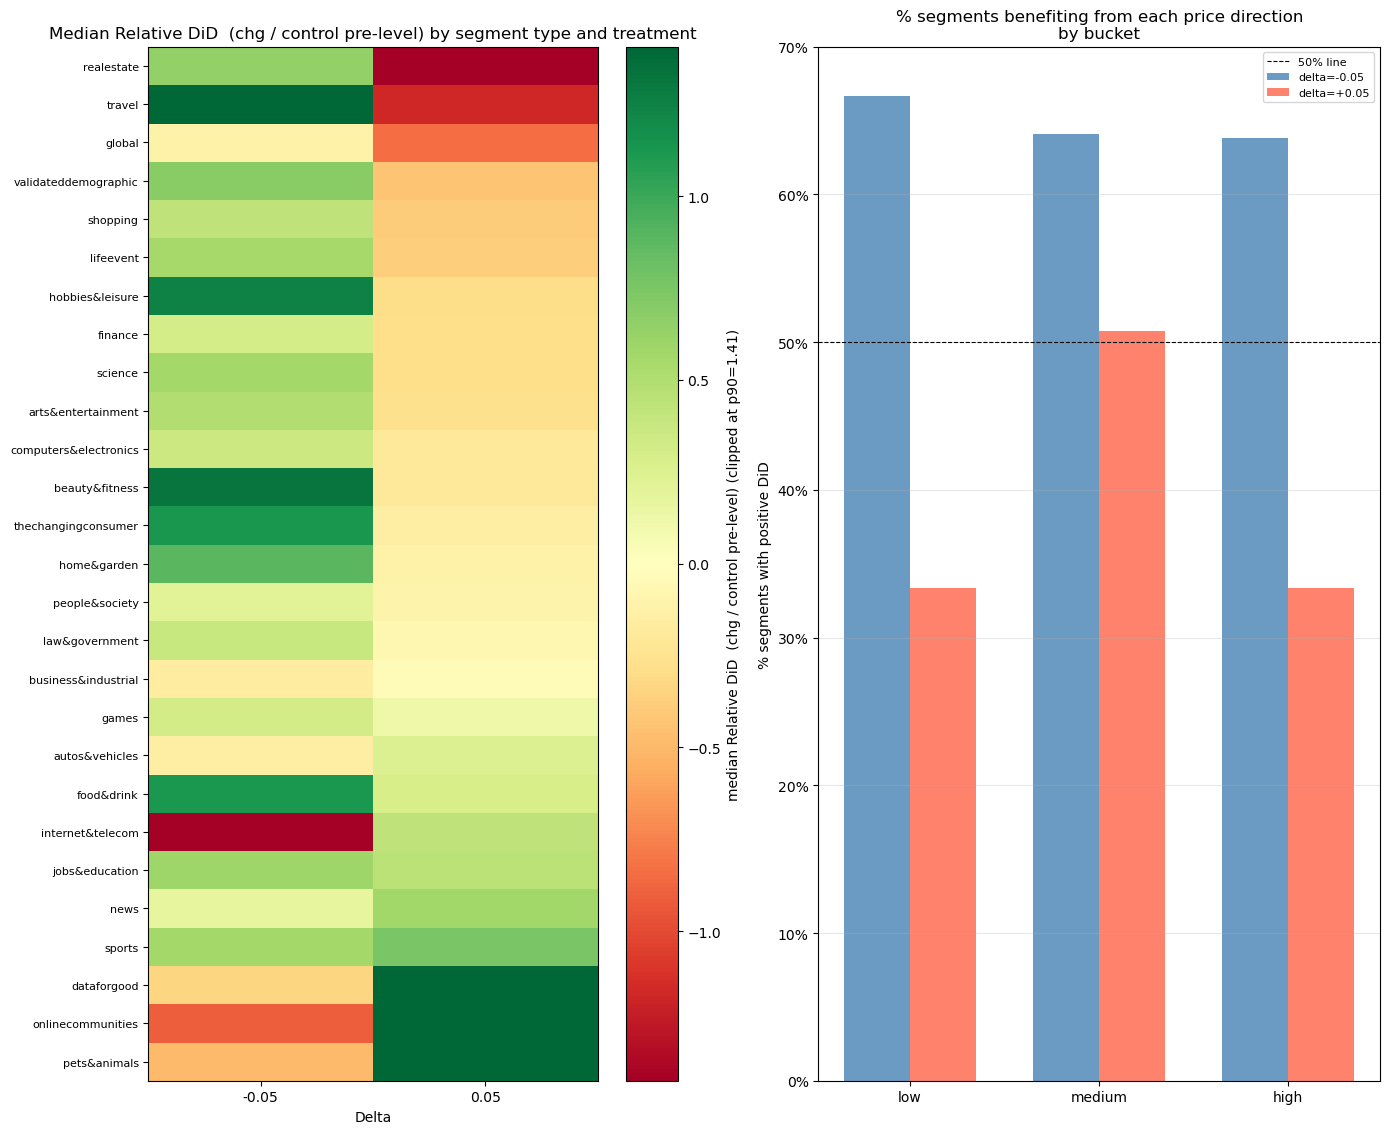

In [65]:
# segment_2 × delta median DiD (used in plots below)
# seg_col = segment_2
hm = (
    did_b[did_b['delta'] != 0]
    .groupby([seg_col, 'delta'])[did_col]
    .median()
    .unstack('delta')
    .dropna()
    .sort_values(did_b['delta'].max())
)

# ── 3. segment-type preference ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(hm) * 0.35 + 2)))

# left: heatmap — median DiD per (segment_2, delta)
vmax = np.percentile(abs(hm.values), 90)
im = axes[0].imshow(hm.values, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=axes[0], label=f'median {did_label} (clipped at p90={vmax:.2f})')
axes[0].set_xticks(range(len(hm.columns)))
axes[0].set_xticklabels([str(c) for c in hm.columns])
axes[0].set_yticks(range(len(hm.index)))
axes[0].set_yticklabels(hm.index, fontsize=8)
axes[0].set_xlabel('Delta')
axes[0].set_title(f'Median {did_label} by segment type and treatment')

# right: % of segments with positive DiD per (bucket, delta)
ax = axes[1]
x = np.arange(len(buckets))
width = 0.35
for di, (d, color) in enumerate(zip([-0.05, 0.05], ['steelblue', 'tomato'])):
    pcts = []
    for b in buckets:
        vals = did_b[(did_b['bucket'] == b) & (did_b['delta'] == d)][did_col].dropna()
        pcts.append((vals > 0).mean() * 100 if len(vals) > 0 else 0)
    ax.bar(x + di * width, pcts, width, label=f'delta={d:+.2f}', color=color, alpha=0.8)
ax.axhline(50, color='black', linewidth=0.8, linestyle='--', label='50% line')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(buckets)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('% segments with positive DiD')
ax.set_title('% segments benefiting from each price direction\nby bucket')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
